# 07 — Mini scaling law, domain-mix, and multi-epoch overfitting (Wave G)

**Phase 5, Wave G — the last ablation wave.** Three small studies, all run on the RTX 5090,
all sharing one theme: *what happens as you change how much data / how many parameters / how
many passes over a fixed pool a model gets.* This notebook reproduces `scripts/plot_wave_g.py`'s
numbers with commentary, for the phase-9 recipe (`docs/results/recipe.md`) and for revision.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent


def curve(run_id: str, key: str = "val_loss") -> tuple[list[float], list[float]]:
    toks, vals = [], []
    with open(ROOT / "experiments" / run_id / "metrics.jsonl") as f:
        for line in f:
            d = json.loads(line)
            if d.get(key) is not None:
                toks.append(d["tokens_seen"] / 1e6)
                vals.append(d[key])
    return toks, vals


def final_val(run_id: str) -> float:
    return curve(run_id)[1][-1]


def best_val(run_id: str) -> tuple[float, float]:
    toks, vals = curve(run_id)
    i = min(range(len(vals)), key=lambda i: vals[i])
    return vals[i], toks[i]


## 1. Domain-mix ablation (RW-4)

**The question:** the user wants a finance/self-help/wisdom-flavored model. How much of the
training stream should that domain content occupy before it starts costing *general*
quality? RW-4 sat open since phase 1 waiting on book picks — this session curated **62
public-domain books** (Finance/Investing/Economics/Business + Self-Help/Personal-
Development/Wisdom-practical categories, sourced from local Gutenberg catalog data) as a
deliberately different register from the 112-book academic-philosophy corpus already in use.

**Design note:** this ablation uses a *smaller* fixed token budget (49.15M, not the usual
~98.3M) than every other S-tier wave. Why: the domain pool is only 6.76M raw tokens, and the
phase-5 spec's own "domain repetition ≤4 epochs" design rule would be broken by the 50%-share
point at the standard budget (50% of 98.3M = 49M domain tokens ≈ 7.3 epochs). Shrinking the
total budget keeps every share point, including 50%, honest. **This means these val_loss
numbers are only comparable to each other, not to any other wave's noise floor.**

`sources: [books_dict weight=1-s, domain_books weight=s]` for `s` in {0, 0.10, 0.25, 0.50};
eval always against the *general* val set (books+dictionary), since the question is "what does
this cost general quality," not domain quality (a domain-specific probe is phase-6 work).

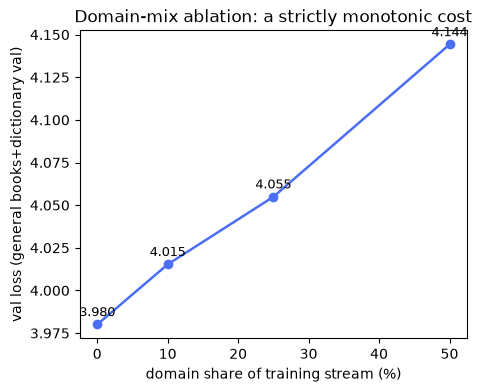

deltas vs 0% control: ['+0.0000', '+0.0352', '+0.0749', '+0.1642']


In [2]:
mix_runs = [
    (0, "20260716_p5_s-wave-g-domainmix-00"),
    (10, "20260716_p5_s-wave-g-domainmix-10"),
    (25, "20260716_p5_s-wave-g-domainmix-25"),
    (50, "20260716_p5_s-wave-g-domainmix-50"),
]
shares = [m[0] for m in mix_runs]
mix_losses = [final_val(m[1]) for m in mix_runs]

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(shares, mix_losses, "o-", color="#4C6EF5", lw=1.8)
for s, l in zip(shares, mix_losses):
    ax.annotate(f"{l:.3f}", (s, l), textcoords="offset points", xytext=(0, 6), ha="center", fontsize=9)
ax.set_xlabel("domain share of training stream (%)")
ax.set_ylabel("val loss (general books+dictionary val)")
ax.set_title("Domain-mix ablation: a strictly monotonic cost")
plt.show()

print("deltas vs 0% control:", [f"{l - mix_losses[0]:+.4f}" for l in mix_losses])


**Result: a clean, strictly monotonic dose-response curve.** Every step up in domain share
costs general val loss — there's no "free" amount of domain flavor. The 50% point's +0.164 gap
is over 8x the D-035 noise floor (a scale reference only, since that floor was measured at a
different token budget). A qualitative check of `experiments/20260716_p5_s-wave-g-domainmix-50/
samples/step_000700.txt` shows finance/economics-inflected phrasing ("Export of the State",
trade/currency language) even at just 49M training tokens — the mix is visibly steering
generation, not just moving a metric.

**Takeaway for phase 9:** budget domain share in the **10-25%** range for the capstone, not
50% — the cost keeps climbing with no sign of a plateau in this sweep. See `docs/results/
recipe.md` for the full recommendation.

## 2. Multi-epoch overfitting lab

**The question:** the phase-5 spec asks to "watch the train/val gap open" as a small, fixed
pool gets repeated more times. Uses `data/clean/books` ONLY (no dictionary — its short,
structured entries would confound a pure prose-memorization study), 14,141,233 tokens, at
1/4/16 epochs (216/864/3456 steps). Eval against the matching `books_only_val.bin` split, not
the general val set, for an apples-to-apples train/val comparison on the exact distribution
the model trained on.

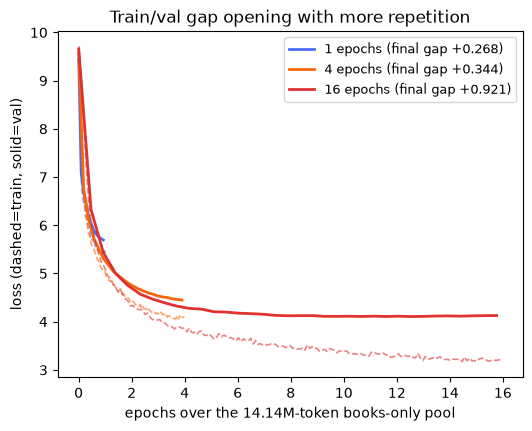

 1 epochs: train=5.427 val=5.695 gap=+0.268
 4 epochs: train=4.104 val=4.448 gap=+0.344
16 epochs: train=3.207 val=4.128 gap=+0.921


In [3]:
epoch_runs = [
    (1, "20260716_p5_s-wave-g-epochs-01"),
    (4, "20260716_p5_s-wave-g-epochs-04"),
    (16, "20260716_p5_s-wave-g-epochs-16"),
]
colors = ["#4C6EF5", "#F76707", "#E03131"]
pool_m = 14.141233

fig, ax = plt.subplots(figsize=(6, 4.5))
for (n_epochs, run_id), color in zip(epoch_runs, colors):
    t_tr, v_tr = curve(run_id, "train_loss")
    t_va, v_va = curve(run_id, "val_loss")
    ax.plot([t / pool_m for t in t_tr], v_tr, color=color, lw=1.2, ls="--", alpha=0.6)
    gap = v_va[-1] - v_tr[-1]
    ax.plot([t / pool_m for t in t_va], v_va, color=color, lw=2.0,
            label=f"{n_epochs} epochs (final gap {gap:+.3f})")
ax.set_xlabel("epochs over the 14.14M-token books-only pool")
ax.set_ylabel("loss (dashed=train, solid=val)")
ax.set_title("Train/val gap opening with more repetition")
ax.legend(fontsize=9)
plt.show()

for n_epochs, run_id in epoch_runs:
    v_tr = curve(run_id, "train_loss")[1][-1]
    v_va = curve(run_id, "val_loss")[1][-1]
    print(f"{n_epochs:2d} epochs: train={v_tr:.3f} val={v_va:.3f} gap={v_va - v_tr:+.3f}")


**Result: the gap opens exactly as predicted — 0.268 → 0.344 → 0.921 — but notice what's
*not* happening.** Val loss itself never gets worse; it plateaus (5.695 → 4.448 → 4.128) while
train loss keeps dropping (5.427 → 4.104 → 3.207). Most of the achievable val improvement
happens in the first few epochs — going from 4 to 16 epochs buys much less val improvement
(4.448 → 4.128) than 1 to 4 did (5.695 → 4.448), even though train loss keeps falling steadily
the whole time. **The train/val gap is the earlier, more sensitive overfitting signal** — you'd
miss real overfitting if you only watched val loss for it to go back up.

Contrast this with section 3 below, where val loss *does* turn around and rise — that only
happens once model capacity is large enough relative to the (repeated) pool, which the S-tier
model at this size isn't, yet.

## 3. Mini scaling law

**The question:** how does val loss scale with parameter count at a *fixed* token budget?
Kaplan (2020) and Chinchilla (2022) fit `L(N) = a*N^-alpha + c` for large-scale, mostly-fresh-
token training; this is a "mini" version at 4 points (5/10/25/50M params), fixed 200M tokens
(~11.3 epochs over the *same* 17.66M-token books+dictionary pool every other S-tier ablation
uses — the SAME repetition at every N, so only param count varies), and `lr` held fixed at 1e-3
across all sizes (not muP-retuned per size — a real caveat, larger models often want smaller lr
or more warmup to realize their full capacity).

10M reuses `configs/model_s.yaml` directly (the project's own battle-tested S-tier shape);
5M/25M/50M are new configs sized by a parameter-count search (`head_dim=64` fixed, tied
embeddings, vocab=16000 — same conventions as every other tier).

In [4]:
scale_runs = [
    (4_999_168, "20260716_p5_scaling-5m"),
    (9_713_472, "20260716_p5_scaling-10m"),
    (24_786_240, "20260716_p5_scaling-25m"),
    (50_400_384, "20260716_p5_scaling-50m"),
]

print(f"{'N':>10} {'best_val':>10} {'@ tokens(M)':>12} {'final_val':>10} {'overfit_gap':>12}")
for n, run_id in scale_runs:
    b, tok_at_best = best_val(run_id)
    f = final_val(run_id)
    print(f"{n/1e6:8.2f}M {b:10.4f} {tok_at_best:12.1f} {f:10.4f} {f - b:+12.4f}")


         N   best_val  @ tokens(M)  final_val  overfit_gap
    5.00M     3.4031        196.7     3.4031      +0.0000
    9.71M     3.2663        196.7     3.2663      +0.0000
   24.79M     3.1655        157.4     3.1789      +0.0134
   50.40M     3.1701        108.2     3.2789      +0.1088


**Look at that last column.** The 5M and 10M models are still monotonically improving at the
end of the 200M-token budget (`overfit_gap` = 0.0000 — best and final are the same step). The
25M model peaks at step 2400 (~157M tokens, ~8.9 epochs) then WORSENS by +0.013 before the
budget runs out. **The 50M model peaks at step 1650 — barely past HALF its budget (~108M
tokens, ~6.1 epochs) — then worsens by +0.109** while its train loss keeps falling to 2.285,
the lowest of any size tested.

**This is the headline finding of the whole wave, not the fitted exponent:** at a fixed, small,
heavily-repeated token budget, *bigger models overfit faster, not slower*. This directly
mirrors the project's own already-established "Muennighoff ceiling" idea (see `docs/DECISIONS.md`
D-015/RW-1: return on repeated data diminishes past ~4 epochs) — except here it's showing up as
a function of *model size*, not just repetition count. A model with enough capacity starts
memorizing the specific 17.66M tokens rather than generalizing from them, and it does so sooner
the more capacity it has relative to the pool.

**Why this matters for the fit below:** if we used each run's *final* val_loss, the 50M point
would look worse than the 25M point — a real, measured number, but one that describes
"how much this model overfit by step 3050," not "how good is this model's ceiling at this
capacity." We fit on the *best* (early-stopped) value instead, which is the standard practice
this discrepancy exists specifically to justify.

L(N) = 11909.67 * N^-0.6940 + 3.1021   (Chinchilla's own alpha ~= 0.34)


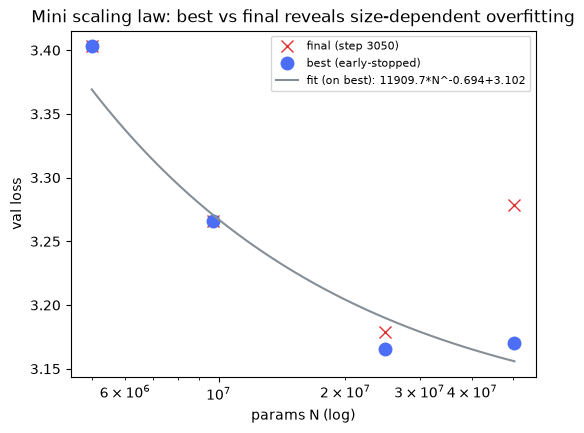

In [5]:
def power_law(n, a, alpha, c):
    return a * np.power(n, -alpha) + c


def fit_power_law(ns, ls):
    """Grid-search the irreducible-loss constant c (numpy-only, no scipy): for each candidate
    c < min(ls), log(L - c) = log(a) - alpha*log(N) is linear, solved by np.polyfit. Pick the c
    minimizing squared residual in loss-space (the scale we actually report)."""
    log_n = np.log(ns)
    best = None
    for c in np.linspace(0.0, ls.min() * 0.98, 400):
        residual = ls - c
        if (residual <= 0).any():
            continue
        slope, intercept = np.polyfit(log_n, np.log(residual), 1)
        alpha, a = -slope, np.exp(intercept)
        sse = float(np.sum((power_law(ns, a, alpha, c) - ls) ** 2))
        if best is None or sse < best[0]:
            best = (sse, a, alpha, c)
    _, a, alpha, c = best
    return a, alpha, c


ns = np.array([r[0] for r in scale_runs], dtype=float)
ls_best = np.array([best_val(r[1])[0] for r in scale_runs])
ls_final = np.array([final_val(r[1]) for r in scale_runs])

a, alpha, c = fit_power_law(ns, ls_best)
print(f"L(N) = {a:.2f} * N^-{alpha:.4f} + {c:.4f}   (Chinchilla's own alpha ~= 0.34)")

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(ns, ls_final, "x", color="#E03131", ms=9, label="final (step 3050)")
ax.plot(ns, ls_best, "o", color="#4C6EF5", ms=9, label="best (early-stopped)")
n_grid = np.logspace(np.log10(ns.min()), np.log10(ns.max()), 100)
ax.plot(n_grid, power_law(n_grid, a, alpha, c), "-", color="#868E96", lw=1.5,
        label=f"fit (on best): {a:.1f}*N^-{alpha:.3f}+{c:.3f}")
ax.set_xscale("log")
ax.set_xlabel("params N (log)")
ax.set_ylabel("val loss")
ax.set_title("Mini scaling law: best vs final reveals size-dependent overfitting")
ax.legend(fontsize=8)
plt.show()


**Reading the fitted exponent honestly:** alpha ≈ 0.69 here is much steeper (and noisier)
than Chinchilla's ~0.34 — expected from only 4 points spanning one order of magnitude, a fixed
(not muP-scaled) learning rate, and a data-constrained rather than fresh-token regime. Treat
this fit as a *qualitative* "returns diminish with scale" signal for this project's specific
setup, not something to extrapolate precisely out to L-tier's ~100M params.

**What DOES extrapolate, qualitatively:** repetition tolerance likely shrinks, not grows, as
parameter count rises toward L-tier. If 50M already overfits a repeated 17.66M-token pool by
step 1650, L-tier's ~100M params will need either genuinely fresh tokens or a much smaller
repetition budget than this wave's ~11.3 epochs — see `docs/results/recipe.md`'s data-budget
recommendation for the capstone.

## Summary — what this wave settles

1. **Domain-mix (RW-4):** a clean monotonic tradeoff between domain flavor and general quality
   — no free lunch at any tested share. Recommend 10-25% for the capstone.
2. **Multi-epoch overfitting:** the train/val *gap* is the sensitive signal, not val loss level
   — val can plateau (not worsen) for a long time even as the gap opens badly.
3. **Mini scaling law:** bigger models overfit a small, fixed, repeated token pool *faster*, not
   slower — the real reason to plan for fresh tokens (or much lower repetition) at L-tier, more
   important than the fitted alpha's precise value.

All three findings, plus every other wave's, are consolidated in `docs/results/recipe.md` —
phase 9's starting point.